In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from sklearn.utils import check_random_state
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

plt.rcParams.update({"figure.dpi": 120,"font.size": 11,"axes.spines.top": False,"axes.spines.right": False})

In [2]:
def make_dataset(n_points, random_state=None):
    random_state = check_random_state(random_state)
    X, y = make_moons(n_samples=n_points, noise=0.2, random_state=random_state)
    X = 2 * X
    theta = np.pi / 6
    R = np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta),  np.cos(theta)]])
    X = X @ R
    perm = np.arange(n_points)
    random_state.shuffle(perm)
    return X[perm], y[perm]

In [3]:
bg_top = mpl.colormaps["Oranges_r"]
bg_bottom = mpl.colormaps["Blues"]
bg_map = ListedColormap(np.vstack((bg_top(np.linspace(.25, 1., 128)),bg_bottom(np.linspace(0., .75, 128)))))
sc_map = ListedColormap(["#ff8000", "DodgerBlue"])


def decision_field(est, grid):
    if hasattr(est, "predict_proba"):
        return est.predict_proba(grid)[:, 1]
    return np.clip(est.predict(grid), 0, 1)


def plot_boundary(ax, est, X, y, title, step=0.05):
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),np.arange(y_min, y_max, step))
    Z = decision_field(est, np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.set_aspect("equal", adjustable="box")
    ax.contourf(xx, yy, Z, levels=11, cmap=bg_map, alpha=.8, vmin=0, vmax=1)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.2)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=sc_map, edgecolor="black", s=12, linewidth=.4)
    ax.set(xlim=(xx.min(), xx.max()), ylim=(yy.min(), yy.max()),xlabel="$x_0$", ylabel="$x_1$", title=title)

In [4]:
X, y = make_dataset(1500, random_state=0)
X_train, X_test = X[:1200], X[1200:]
y_train, y_test = y[:1200], y[1200:]

models = {
    "Linear Regression": LinearRegression().fit(X_train, y_train),
    "k-NN ($k=15$)": KNeighborsClassifier(n_neighbors=15).fit(X_train, y_train),
    "Decision Tree ($d=4$)": DecisionTreeClassifier(max_depth=4, random_state=0).fit(X_train, y_train),
}

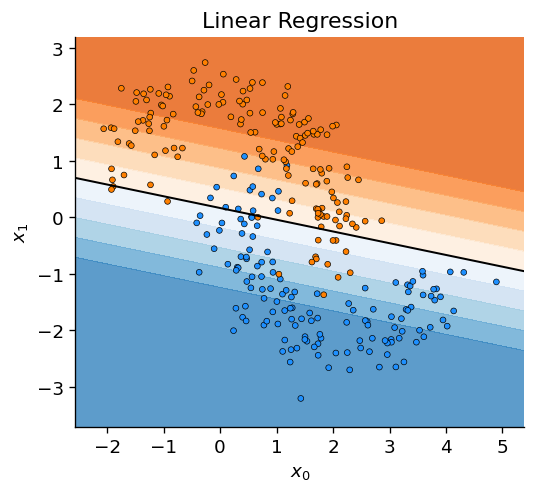

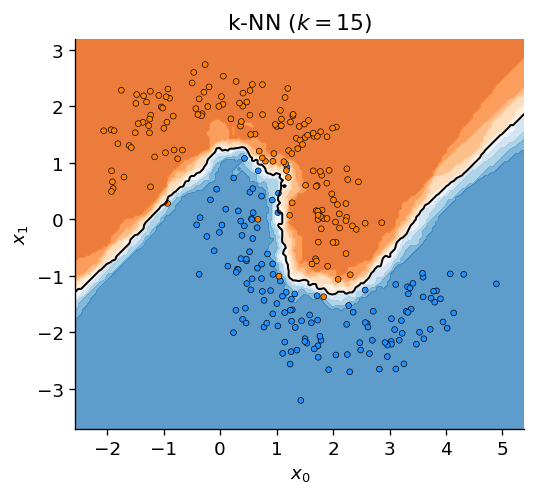

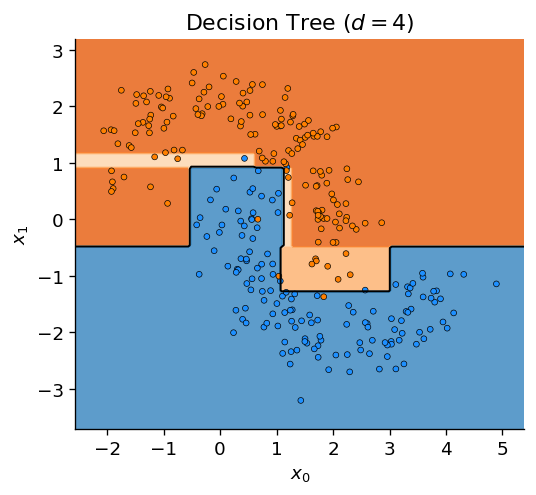

In [5]:
names = ["linear_regression", "knn", "decision_tree"]
for (title, est), name in zip(models.items(), names):
    fig, ax = plt.subplots(figsize=(4.6, 4.6))
    plot_boundary(ax, est, X_test, y_test, title)
    fig.tight_layout()
    fig.savefig(f"boundary_{name}.pdf", transparent=True)
    fig.savefig(f"boundary_{name}.png", dpi=200)
    plt.show()

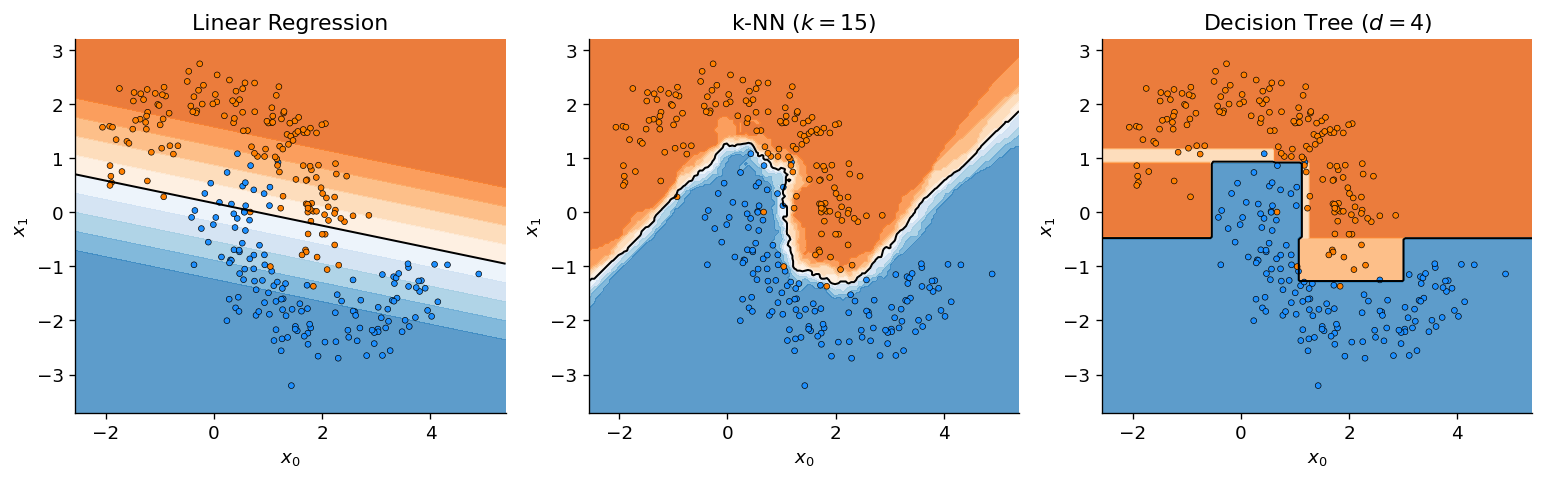

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, (title, est) in zip(axes, models.items()):
    plot_boundary(ax, est, X_test, y_test, title)
fig.tight_layout()
fig.savefig("boundary_comparison.pdf", transparent=True)
fig.savefig("boundary_comparison.png", dpi=200)
plt.show()